In [1]:
suppressPackageStartupMessages({
  library(data.table)
  library(dplyr)
  library(ggplot2)
  library(tidyr)
  library(grid)
  library(gtable)
})

In [2]:
# Load data
df <- fread('../../data/figure-inputs/figure_2/cnv_summary_by_subject.csv')

# Pivot to long format
df_long <- df %>%
  pivot_longer(cols = starts_with('bin_'), names_to = 'bin', values_to = 'cnv_value') %>%
  mutate(bin_num = as.integer(gsub('bin_', '', bin)))

# Order subjects with Healthy at bottom
subject_order <- c('Healthy\nExternal', sort(setdiff(df$subject, 'Healthy External Atlas')))
df_long$subject <- factor(
  ifelse(df_long$subject == 'Healthy External Atlas', 'Healthy\nExternal', as.character(df_long$subject)),
  levels = subject_order
)

# Chromosome positions (0-indexed -> 1-indexed)
chr_pos <- c(
  chr1 = 1, chr2 = 37, chr3 = 60, chr4 = 80, chr5 = 91, chr6 = 105,
  chr7 = 119, chr8 = 134, chr9 = 144, chr10 = 155, chr11 = 166,
  chr12 = 188, chr13 = 205, chr14 = 211, chr15 = 226, chr16 = 234,
  chr17 = 247, chr18 = 265, chr19 = 267, chr20 = 290, chr21 = 297,
  chr22 = 299
)

n_bins <- 305

chr_ends <- c(chr_pos[-1] - 1, n_bins)
chr_mids <- (chr_pos + chr_ends) / 2
chr_labels <- names(chr_pos)
chr_boundaries <- chr_pos[-1] - 0.5

In [3]:
subject_color_map <- c(
  'FH1001' = '#1f77b4',
  'FH1002' = '#ff7f0e',
  'FH1003' = '#279e68',
  'FH1004' = '#d62728',
  'FH1005' = '#aa40fc',
  'FH1006' = '#8c564b',
  'FH1007' = '#e377c2',
  'FH1008' = '#b5bd61',
  'FH1009' = '#17becf',
  'FH1010' = '#aec7e8',
  'FH1011' = '#ffbb78',
  'FH1012' = '#98df8a',
  'FH1014' = '#ff9896',
  'FH1016' = '#c5b0d5',
  'FH1017' = '#c49c94',
  'FH1018' = '#f7b6d2',
  'FH1021' = '#dbdb8d'
)

subject_color_map_with_healthy <- c(subject_color_map, 'Healthy\nExternal' = '#06402B')
y_colors <- subject_color_map_with_healthy[subject_order]

In [4]:
# Calculate actual data range
vmin <- quantile(df_long$cnv_value, 0.01, na.rm = TRUE)
vmax <- quantile(df_long$cnv_value, 0.99, na.rm = TRUE)

In [5]:
options(repr.plot.width = 16, repr.plot.height = 8, repr.plot.res = 200)

p <- ggplot(df_long, aes(x = bin_num, y = subject, fill = cnv_value)) +
  geom_raster() +
  geom_vline(xintercept = chr_boundaries, color = 'black', linewidth = 0.3) +
  scale_fill_gradient2(
    low = 'navy', mid = 'white', high = 'red4',
    midpoint = 0,
    limits = c(vmin, vmax),
    oob = scales::squish,
    na.value = 'white',
    name = NULL,  # remove legend heading
    breaks = c(vmax, 0, vmin),
    labels = c('Gain', '', 'Loss')  # top = Gain, bottom = Loss
  ) +
  scale_x_continuous(
    breaks = chr_mids,
    labels = gsub('chr', 'Chr ', chr_labels),
    expand = c(0, 0),
    sec.axis = dup_axis(name = '')
  ) +
  scale_y_discrete(expand = c(0, 0)) +
  coord_cartesian(xlim = c(0.5, n_bins + 0.5), clip = 'off') +
  labs(x = '', y = '', title = '') +
  theme_minimal(base_size = 14) +
  theme(
    axis.text.y = element_text(size = 12, face = 'bold', color = 'black'),
    axis.text.x.top = element_text(size = 12, face = 'bold', color = 'black', angle = 90, vjust = 0.5, hjust = 0),
    axis.text.x.bottom = element_blank(),
    axis.ticks.x.bottom = element_blank(),
    panel.grid = element_blank(),
    panel.border = element_rect(color = 'black', fill = NA, linewidth = 0.6),
    plot.margin = margin(t = 0, r = 5, b = 5, l = 20, unit = 'pt'),
    legend.title = element_blank()  # extra safety to remove legend title
  )

# Build gtable
gb <- ggplot_build(p)
gt <- ggplot_gtable(gb)

# Find the y-axis and panel positions
yaxis_col <- gt$layout$l[gt$layout$name == 'axis-l']
panel_row_t <- gt$layout$t[gt$layout$name == 'panel']
panel_row_b <- gt$layout$b[gt$layout$name == 'panel']

n_subjects <- length(subject_order)

# Insert new column AFTER the y-axis (between y-axis text and panel)
gt <- gtable_add_cols(gt, unit(8, 'pt'), pos = yaxis_col)
strip_col <- yaxis_col + 1

for (i in seq_along(subject_order)) {
  subj <- subject_order[i]
  col <- subject_color_map_with_healthy[subj]
  
  y_mid <- (i - 0.5) / n_subjects
  
  strip_grob <- rectGrob(
    x = unit(0.5, 'npc'),
    y = unit(y_mid, 'npc'),
    width = unit(1, 'npc'),
    height = unit(1 / n_subjects, 'npc'),
    gp = gpar(
      fill = col,
      col = 'black',
      lwd = 1.5
    )
  )
  
  gt <- gtable_add_grob(
    gt, strip_grob,
    t = panel_row_t,
    b = panel_row_b,
    l = strip_col,
    r = strip_col,
    clip = 'off',
    name = paste0('strip_', i)
  )
}

pdf("../../data/figure-outputs/supplementary-1/sup_1b.pdf", width = 16, height = 8)
grid.newpage()
grid.draw(gt)
dev.off()

pdf 
  2

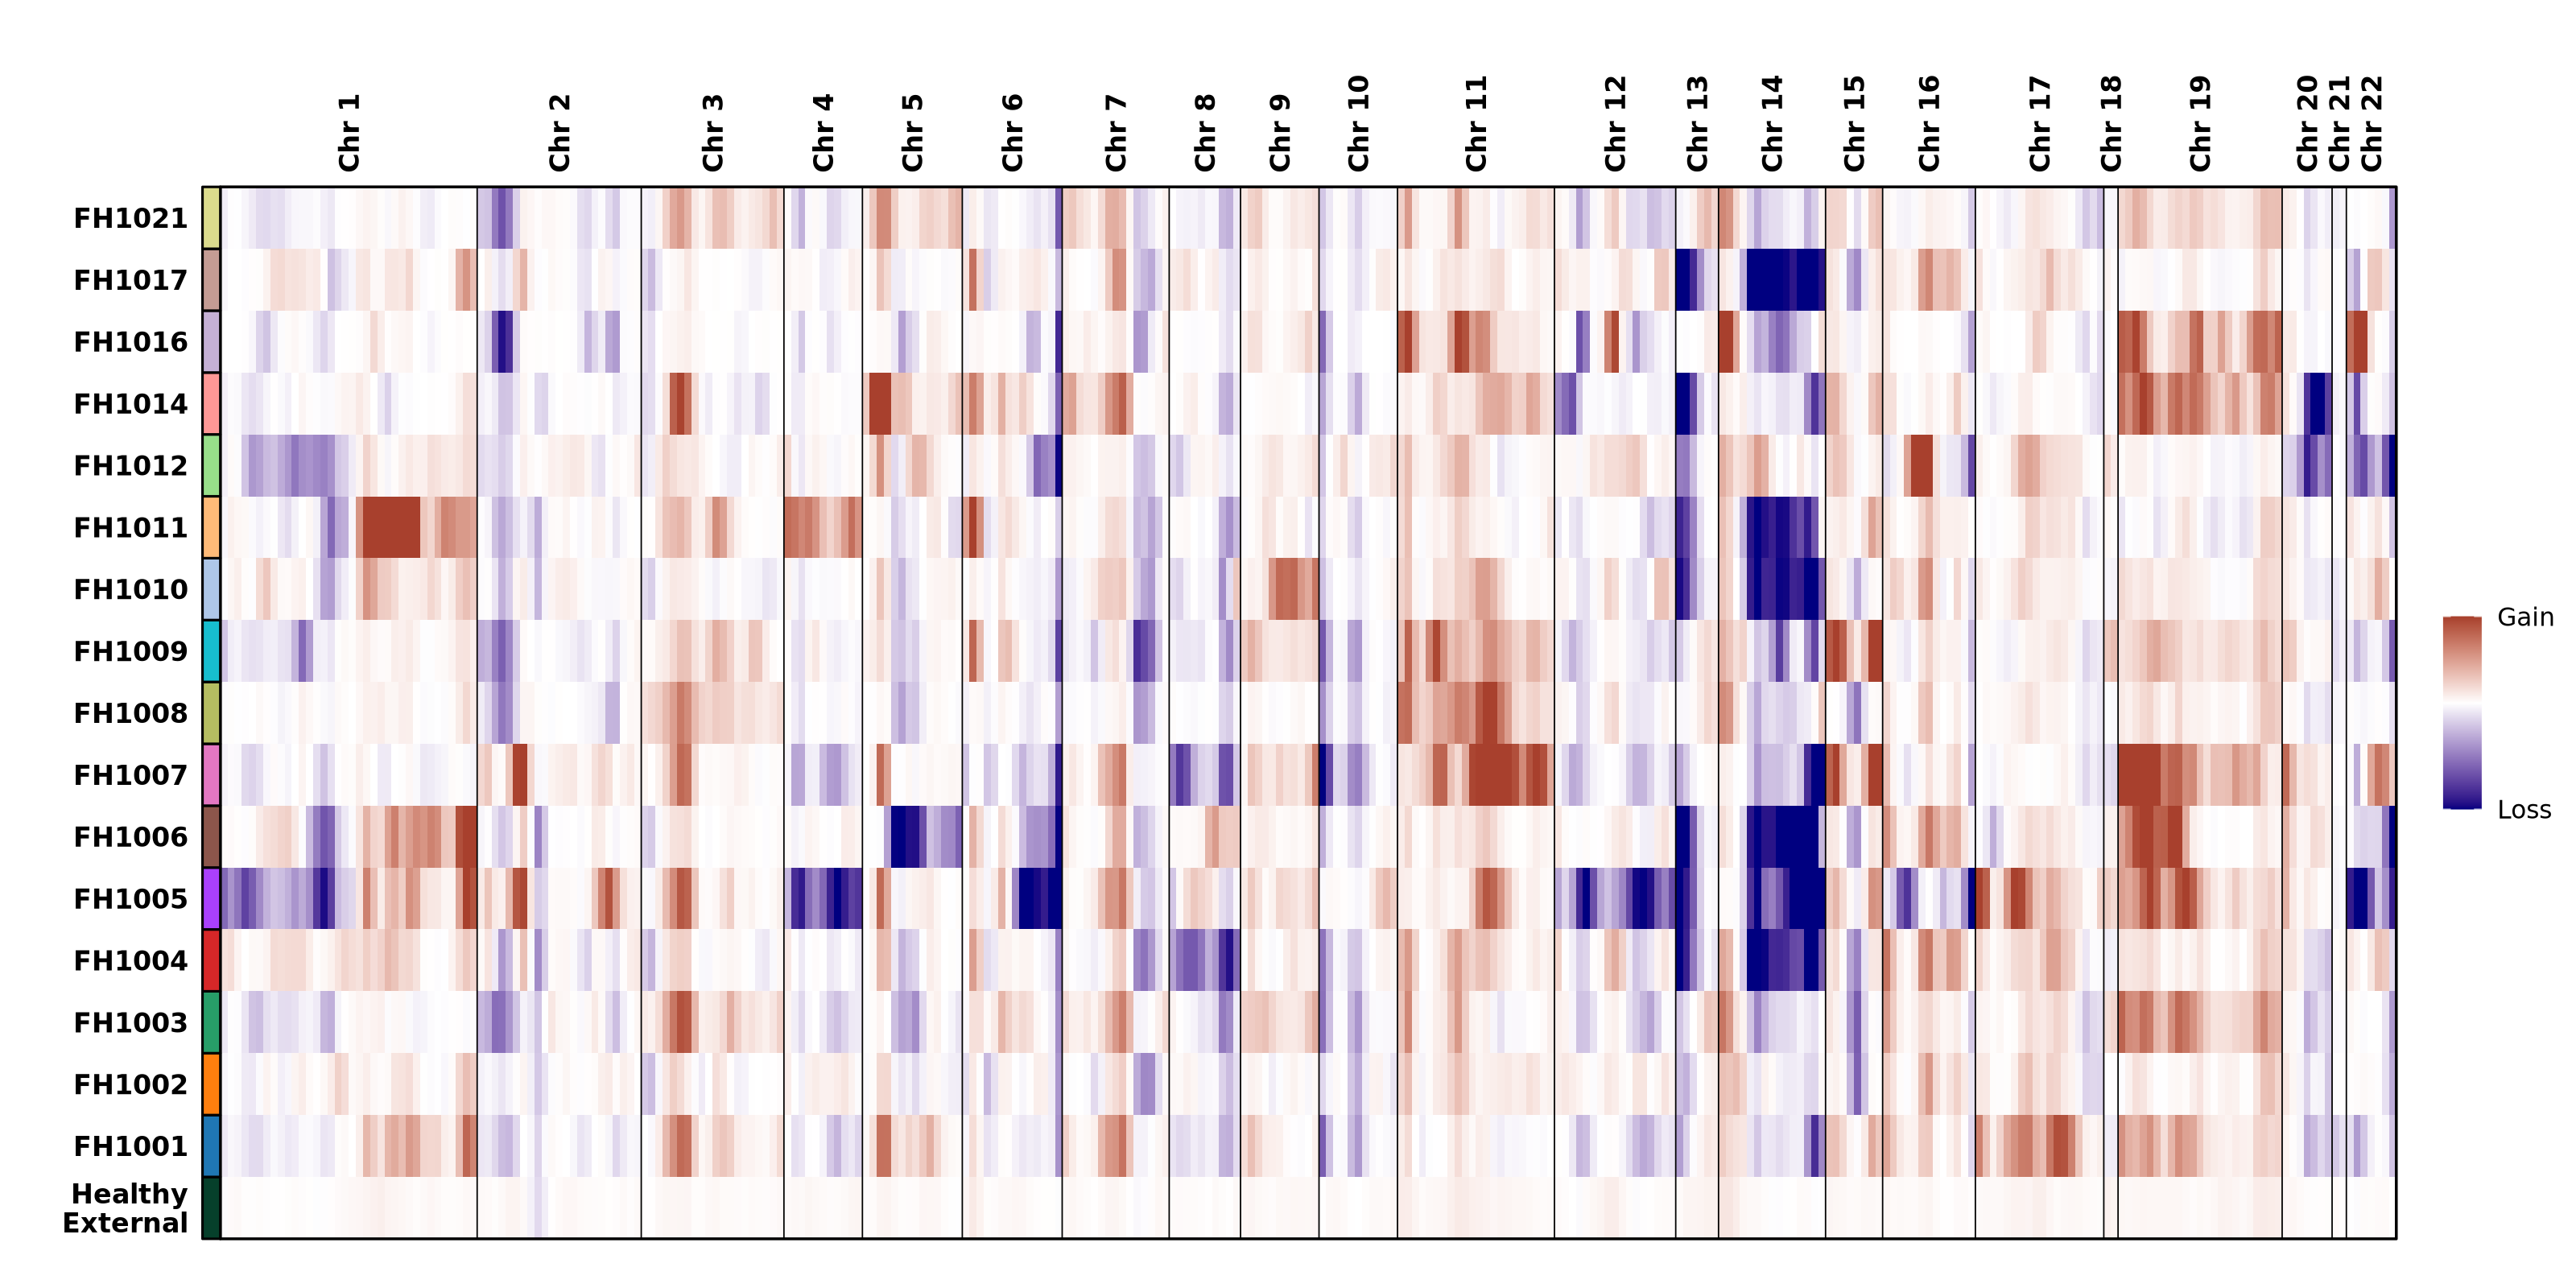

In [6]:
grid.draw(gt)